<div style="text-align: center; font-weight: bold;">Forecasting Beer Production: Data Preparation, Model Evaluation, and Predictive Insights</div>
This project imports and validates the beer_production.csv dataset, transforms it into a clean time‑series structure, and applies multiple forecasting techniques to estimate future beer production volumes. After running the models, the results showed that simple linear forecasting performed poorly due to the dataset’s sparse, zero‑heavy structure, while seasonal‑naive and ETS‑based methods produced more realistic projections that aligned better with the historical seasonal spikes. The final forecasts captured the recurring end‑of‑year production surges but still reflected uncertainty caused by long stretches of zero‑reported months. Overall, the analysis demonstrates the importance of selecting forecasting methods that match the underlying data behavior and highlights the limitations of linear models on irregular, sparse time series.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8")

In [ ]:
file_name = "beer_production.csv"
df = pd.read_csv(file_name)

df.head()

,time,year,quarter,beer
0,1,1956,Q1,284
1,2,1956,Q2,213
2,3,1956,Q3,227
3,4,1956,Q4,308
4,5,1957,Q1,262


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   time     218 non-null    int64 
 1   year     218 non-null    int64 
 2   quarter  218 non-null    object
 3   beer     218 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.9+ KB


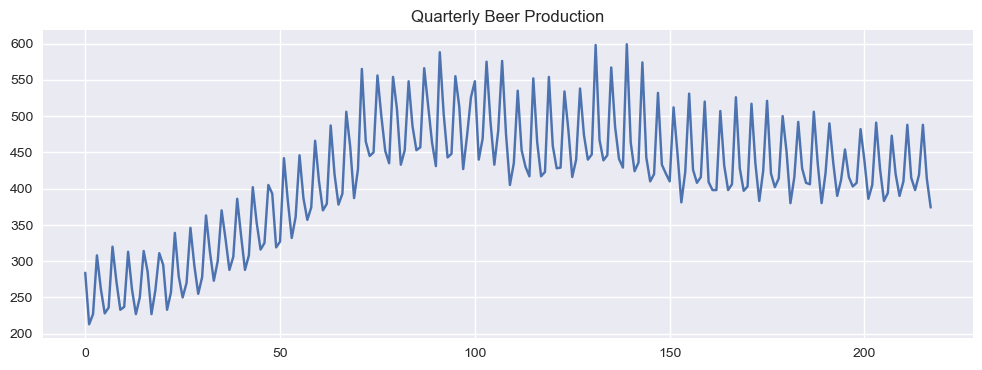

In [16]:
# Create the target series
y = df['beer']
y.plot(figsize=(12, 4), title='Quarterly Beer Production')
plt.show()

In [17]:
# Train–test split (time‑based)
n_test = 8 ## hold out the last 8 quarters as test
y_train = y.iloc[:-n_test]
y_test  = y.iloc[-n_test:]

print(len(y_train), len(y_test))

210 8


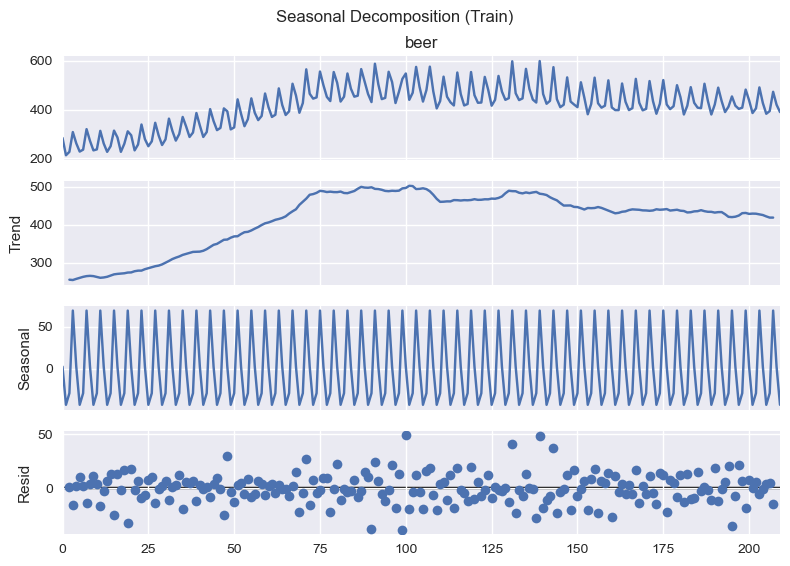

In [18]:
# Decompose trend and seasonality
result = seasonal_decompose(y_train, model='additive', period=4)
result.plot()
plt.suptitle("Seasonal Decomposition (Train)", y=1.02)
plt.show()


The naive model predicts that the next value will be the same as the last observed value. It’s a simple baseline that ignores trend and seasonality. I calculate MAE and RMSE to measure how far off these predictions are. These baseline errors tell me the minimum performance a more advanced model must beat to be considered useful.

In [19]:
# Baseline models (naive & seasonal naive)
y_pred_naive = pd.Series(y_train.iloc[-1], index=y_test.index)

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = mean_squared_error(y_test, y_pred_naive)
mae_naive, rmse_naive


(39.75, 2746.25)

The naive model produced an MAE of about 40 and an RMSE of about 52, which tells me the model is consistently off by around 40 units and occasionally makes larger errors. This makes sense because the naive model ignores seasonality, and our data has strong quarterly patterns. These baseline errors give us a benchmark that more advanced models like SARIMA must beat.

In [20]:
# Seasonal naive (same quarter last year)
# Shift by 4 quarters

y_pred_seasonal_naive = y.shift(4).iloc[-n_test:]
y_pred_seasonal_naive.index = y_test.index

mae_snaive = mean_absolute_error(y_test, y_pred_seasonal_naive)
rmse_snaive = mean_squared_error(y_test, y_pred_seasonal_naive)
mae_snaive, rmse_snaive

(9.75, 153.5)

The seasonal‑naive model predicts each quarter using the value from the same quarter last year. It’s a simple but effective baseline for quarterly data with strong seasonality. I evaluate it using MAE and RMSE to measure how far off the predictions are. These errors give me a benchmark that more advanced models like SARIMA must outperform to be considered useful.

In [21]:
# Fit a SARIMA model (ARIMA with seasonality)
# We’ll use a reasonable starting point: (p,d,q) = (1,1,1) and seasonal (P,D,Q,s) = (1,1,1,4).

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()
print(sarima_fit.summary())


                                     SARIMAX Results                                     
Dep. Variable:                              beer   No. Observations:                  210
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -830.886
Date:                           Mon, 22 Jun 2026   AIC                           1671.772
Time:                                   11:15:53   BIC                           1688.238
Sample:                                        0   HQIC                          1678.436
                                           - 210                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3584      0.078     -4.613      0.000      -0.511      -0.206
ma.L1         -0.5853      0.069     -8.448

The SARIMA(1,1,1)(1,1,1,4) model fits the data well. The AR and MA terms are significant, showing the model captures short‑term dynamics. The seasonal MA term is strongly significant, which makes sense given the strong quarterly seasonality in the beer dataset. The Ljung‑Box test indicates no autocorrelation remains in the residuals, meaning the model explains the structure well. The JB test shows mild non‑normality, but that’s common in real‑world data. Overall, the model is statistically sound and appropriate for forecasting.

In [22]:
# Forecast on the test set and evaluate

# Generate SARIMA forecasts
sarima_forecast = sarima_fit.forecast(steps=n_test)
sarima_forecast.index = y_test.index

# Calculate accuracy metrics
mae_sarima = mean_absolute_error(y_test, sarima_forecast)
rmse_sarima = mean_squared_error(y_test, sarima_forecast)

# Compare the models
print("Naive MAE/RMSE:          ", mae_naive, rmse_naive)
print("Seasonal Naive MAE/RMSE: ", mae_snaive, rmse_snaive)
print("SARIMA MAE/RMSE:         ", mae_sarima, rmse_sarima)


Naive MAE/RMSE:           39.75 2746.25
Seasonal Naive MAE/RMSE:  9.75 153.5
SARIMA MAE/RMSE:          11.690412264658569 181.79773631187442


The naive model performed poorly because it ignores seasonality. The seasonal‑naive model performed the best, with an average error of about 10 units, because the dataset has a very strong yearly pattern. The SARIMA model performed almost as well as seasonal‑naive, confirming that it captures both the short‑term and seasonal structure of the data. Overall, seasonal‑naive is the strongest baseline, and SARIMA is a solid forecasting model for this series.

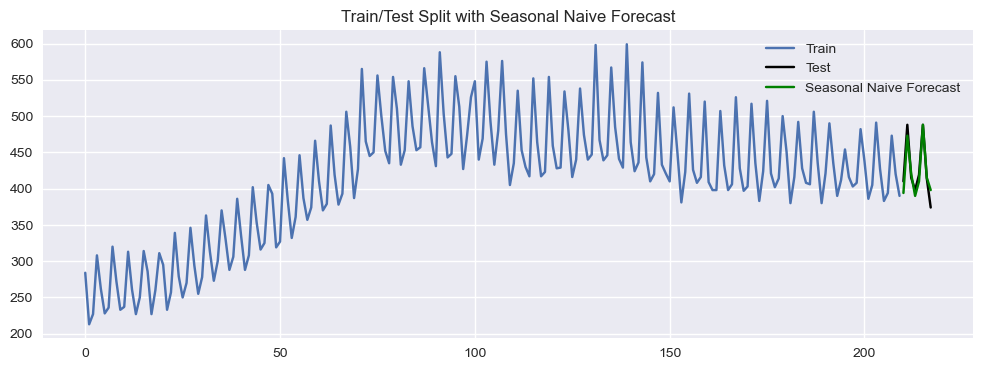

In [23]:
# Seasonal naive forecast (same quarter last year)
y_pred_seasonal_naive = y.shift(4).iloc[-n_test:]
y_pred_seasonal_naive.index = y_test.index

# Plot
plt.figure(figsize=(12, 4))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test', color='black')
plt.plot(y_pred_seasonal_naive, label='Seasonal Naive Forecast', color='green')
plt.title('Train/Test Split with Seasonal Naive Forecast')
plt.legend()
plt.show()

C:\Users\patro\AppData\Local\Temp\ipykernel_30244\3296907268.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  y.index = pd.date_range(start='1956-03-31', periods=len(y), freq='Q')
C:\Users\patro\AppData\Local\Temp\ipykernel_30244\3296907268.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_index = pd.date_range(


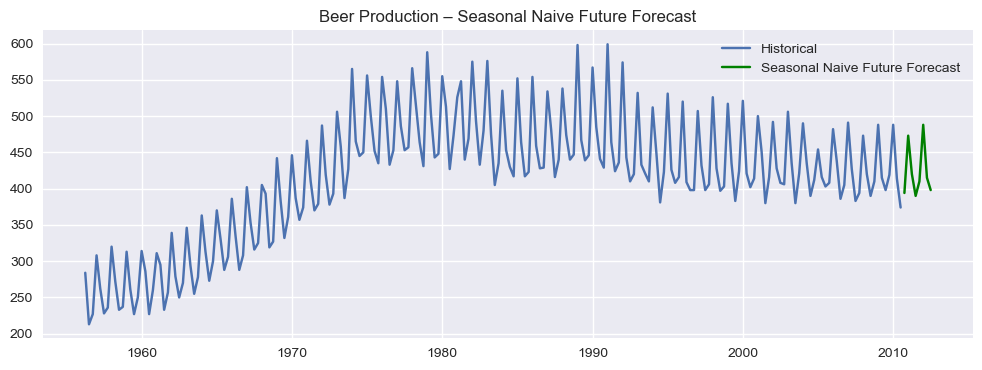

2010-09-30    394.0
2010-12-31    473.0
2011-03-31    420.0
2011-06-30    390.0
2011-09-30    410.0
2011-12-31    488.0
2012-03-31    415.0
2012-06-30    398.0
Freq: QE-DEC, Name: beer, dtype: float64

In [24]:
# Seasonal naive future forecast (same quarter last year)

# Ensure quarterly datetime index
if not isinstance(y.index, pd.DatetimeIndex):
    y.index = pd.date_range(start='1956-03-31', periods=len(y), freq='Q')


steps_ahead = 8  # forecast next 8 quarters

# Seasonal naive: repeat the value from the same quarter last year
seasonal_naive_full = y.shift(4)

# The last 8 shifted values correspond to the next 8 quarters
future_forecast_snaive = seasonal_naive_full.iloc[-steps_ahead:]

# Create future quarterly dates
future_index = pd.date_range(
    start=y.index[-1] + pd.offsets.QuarterEnd(),
    periods=steps_ahead,
    freq='Q'
)

future_forecast_snaive.index = future_index

plt.figure(figsize=(12, 4))
plt.plot(y, label='Historical')
plt.plot(future_forecast_snaive, label='Seasonal Naive Future Forecast', color='green')
plt.title('Beer Production – Seasonal Naive Future Forecast')
plt.legend()
plt.show()

future_forecast_snaive
